# Noise measurements with FastDAC

This notebook implements a user-specified time (default: 10s) measurement on a single channel on a speficied FastDAC for noise.

## Hardware Setup Requirements
1. FastDAC devices:
   - Connected via serial ports
   - Properly configured channels for voltage outputs

2. Experiment connections:
   - Current measurement path through transimpedance amplifier to FastDAC ADC

Adjust the settings in the first section to match your hardware configuration.

In [33]:
# Import required libraries
import time
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from time import sleep
from pathlib import Path
from qcodes import (
    Parameter,
    Measurement,
    Station,
    load_or_create_experiment,
    initialise_or_create_database_at,
)

# FastDAC import
from FastDAC import FastDAC

# PyVISA for instrument control if needed
# import pyvisa
# rm = pyvisa.ResourceManager()

t_acqu = 10 # acquisition time in second
meas_seg = 6
total_meas_time = 3600 * 10
t = np.arange(start=0, stop=t_acqu, step=1/1000)
station = Station()

initialise_or_create_database_at("C:/Users/Measurement6/Nextcloud2/Lab/Data/QSim/2025/20251117_NoiseData/fast_dac_noise.db")
exp = load_or_create_experiment("2D sweep", "SecondBOP12_RC_SHIELD_wo_ferrite_noise_data")
meas = Measurement(exp=exp, station=station)

meas_time = Parameter(name = "meas_time", label = "Measurement Time", unit = "s")
meas_freq = Parameter(name = "meas_freq", label = "Measurement Frequency", unit = "Hz")
meas_rms = Parameter(name = "meas_rms", label = "Measurement RMS", unit = "pA")
trace_data = Parameter(name = "trace_data", label = "Measurement Data", unit = "pA")
fft_data = Parameter(name = "fft_data", label = "FFT Data", unit = "A/Hz^-1/2")
elapsed_time = Parameter(name = "elapsed_time", label = "Elapsed Time", unit = "s")
meas.register_parameter(meas_time)
meas.register_parameter(meas_freq)
meas.register_parameter(elapsed_time)
meas.register_parameter(fft_data, setpoints=(meas_freq, elapsed_time))
meas.register_parameter(trace_data, setpoints=(meas_time, elapsed_time))
meas.register_parameter(meas_rms, setpoints=(elapsed_time,))

(MainThread) Registered meas_time in the Measurement.
(MainThread) Registered meas_freq in the Measurement.
(MainThread) Registered elapsed_time in the Measurement.
(MainThread) Registered fft_data in the Measurement.
(MainThread) Registered trace_data in the Measurement.
(MainThread) Registered meas_rms in the Measurement.


In [2]:
# --- Find available COM ports ---
import serial.tools.list_ports

def list_com_ports():
    """List all available COM ports"""
    ports = serial.tools.list_ports.comports()
    print("\nAvailable COM ports:")
    print("-" * 50)
    for port in ports:
        print(f"Port: {port.device}")
        print(f"Description: {port.description}")
        print(f"Hardware ID: {port.hwid}")
        print("-" * 50)
    return ports

# List available ports to help choose the correct ones
available_ports = list_com_ports()


Available COM ports:
--------------------------------------------------
Port: COM3
Description: USB Serial Port (COM3)
Hardware ID: USB VID:PID=0403:6001 SER=B000ULXXA
--------------------------------------------------
Port: COM11
Description: USB Serial Port (COM11)
Hardware ID: USB VID:PID=0403:6014 SER=5
--------------------------------------------------
Port: COM1
Description: Communications Port (COM1)
Hardware ID: ACPI\PNP0501\0
--------------------------------------------------
Port: COM12
Description: USB Serial Port (COM12)
Hardware ID: USB VID:PID=0403:6014 SER=FT76UU32A
--------------------------------------------------
Port: COM20
Description: 熐✼￿ Port 1 (COM20)
Hardware ID: MXUPSER\MXUPORT\7&1AE68022&0&MXUPORT0000
--------------------------------------------------
Port: COM21
Description: 熐✼￿ Port 2 (COM21)
Hardware ID: MXUPSER\MXUPORT\7&1AE68022&0&MXUPORT0001
--------------------------------------------------
Port: COM22
Description: 熐✼￿ Port 3 (COM22)
Hardware ID: MX

In [3]:
# --- Initialize FastDAC instances ---
# Initialize FastDAC devices with explicit port names for deterministic mapping
baudrate = 1750000
timeout = 60

# Initialize FastDAC devices using manual port specification
print("Initializing FastDAC instances...")
# Replace these port names with your actual COM ports
ports = ["COM12"]  # Update these!
fastdacs = []

for port in ports:
    try:
        dac = FastDAC(port, baudrate=baudrate, timeout=timeout, testing=False)
        dac.SET_CONVERT_TIME_ALL(convertTime=1000) #Defaults to setting the convert time to read from the ADC to 1000 us
        fastdacs.append(dac)
        print(f"Initialized FastDAC on {port}")
        try:
            if hasattr(dac, 'ask'):
                idn = dac.ask('*IDN?')
                print(f"Device identity: {idn}")
        except Exception:
            print(f"Could not get device identity for {port}")
    except Exception as e:
        print(f"Failed to initialize FastDAC on {port}: {e}")
        fastdacs.append(None)

# Print brief status
for i, fd in enumerate(fastdacs):
    if fd is None:
        print(f"FastDAC slot {i}: None")
    else:
        print(f"FastDAC slot {i}: port={getattr(fd, 'port', 'unknown')}")

# --- Contact and Channel Configurations ---
# From original notebook - maintaining same contact naming convention
# You can modify this to match your specific wiring setup
contacts = {
    "C1": (0, 0),    # FastDAC 0, channel 0
    "C2": (1, 1),    # FastDAC 1, channel 1
    # "C3": (0, 2),    # FastDAC 0, channel 2
    # Additional mappings as needed
}

# Global settings (matching original notebook)
ramp_rate_V_per_s = 1.0         # V/s (will be converted to mV/s for FastDAC calls)
gain = 1                # preamp gain #1e8
max_sampling_rate = int(1/(0.001))  # FastDAC sampling rate 1/{Convert_Time}
max_sampling_rate_NIDAC = int(1e6) # NI-DAC Sampling Rate
V_LIMIT = 0.5         # voltage limit in V for safety
I_threshold = 0.5    # current threshold in A #2e-9

print("\nConfiguration complete.")

Initializing FastDAC instances...
FASTDAC_UNIT-SALFI3_SERVICE-GIGA-TEST5
Initialized FastDAC on COM12
FastDAC slot 0: port=COM12

Configuration complete.


## Basic Control Functions

Helper functions for FastDAC control and voltage management

In [5]:
# --- Helper functions for FastDAC control ---
def validate_voltages(values, limit=V_LIMIT):
    """Validate that voltages are within safety limits"""
    if any(abs(np.array(values)) > limit):
        raise ValueError(f"Voltage exceeds limit {limit} V: {values}")

def get_initial_voltages(contacts_map):
    """Return dict of contact -> voltage in V. FastDAC.GET_DAC returns mV."""
    conditions = {}
    for name, (fd_idx, dac_ch) in contacts_map.items():
        fd = fastdacs[fd_idx]
        if fd is None:
            conditions[name] = None
            continue
        try:
            # GET_DAC returns string in mV, convert to V
            v_str = fd.GET_DAC(dac_ch)
            conditions[name] = float(v_str) / 1000.0
        except Exception as e:
            print(f"Error reading {name}: {e}")
            conditions[name] = None
    return conditions

def ramp_channels(channel_names, values_V):
    """Ramp listed channels to target values in V. FastDAC expects mV."""
    if len(values_V) != 1 and len(values_V) != len(channel_names):
        raise ValueError("values_V must be scalar or same length as channels")
    
    vals = values_V if len(values_V) > 1 else [values_V[0]] * len(channel_names)
    validate_voltages(vals)
    
    for ch_name, v in zip(channel_names, vals):
        if ch_name not in contacts:
            raise KeyError(f"Unknown channel {ch_name}")
        fd_idx, dac_ch = contacts[ch_name]
        fd = fastdacs[fd_idx]
        if fd is None:
            print(f"No FastDAC for {ch_name}; skipping")
            continue
            
        target_mV = float(v) * 1000.0  # convert V to mV
        rampRate_mV_per_s = float(ramp_rate_V_per_s) * 1000.0
        
        # Use RAMP_SMART with mV values
        fd.RAMP_SMART(channel=dac_ch, 
                     setPoint=int(round(target_mV)), 
                     rampRate=int(round(rampRate_mV_per_s)))

def ramp_all_channels_to_zero():
    """Ramp all defined channels to zero"""
    for name, (fd_idx, dac_ch) in contacts.items():
        fd = fastdacs[fd_idx]
        if fd is None:
            continue
        fd.RAMP_SMART(channel=dac_ch, setPoint=0, rampRate=int(ramp_rate*1000))

# Print function for diagnostics
def print_channel_status():
    """Print current voltage of all channels"""
    print("\nChannel Status:")
    print("-" * 40)
    print(f"{'Channel':10s} {'Voltage (V)':12s} {'DAC':8s} {'FastDAC':8s}")
    print("-" * 40)
    for name, (fd_idx, dac_ch) in sorted(contacts.items()):
        fd = fastdacs[fd_idx]
        if fd is None:
            v_str = "N/A"
        else:
            try:
                v_mv = float(fd.GET_DAC(dac_ch))
                v_str = f"{v_mv/1000.0:+.3f}"
            except Exception:
                v_str = "ERROR"
        print(f"{name:10s} {v_str:12s} {dac_ch:8d} {fd_idx:8d}")
    print("-" * 40)

In [6]:
# --- FastDAC ADC read helpers ---
def read_fastdac_adc(fd_idx, adc_channel, num_samples=1):
    """Read voltage from FastDAC ADC channel"""
    if fd_idx < 0 or fd_idx >= len(fastdacs):
        raise ValueError(f"Invalid FastDAC index {fd_idx}")
    fd = fastdacs[fd_idx]
    if fd is None:
        raise ValueError(f"No FastDAC at index {fd_idx}")
    
    start_time = time.time()
    readings = []
    try:
        #print(f"Befores point @ {time.time()-start_time:.5f}s")
        # print("Going to read from SPEC_ANA")
        val_array = fd.SPEC_ANA(channels=[adc_channel, ], steps=num_samples)
        # print(val_array)
        #print(f"After points @ {time.time()-start_time:.5f}s")
        readings = np.array(val_array[adc_channel])/1000
    except Exception as e:
        print(f"Error reading FastDAC {fd_idx} ADC {adc_channel}: {e}")
        readings.append(np.nan)

    return readings

def read_measurement_device(device_spec, num_samples=1, v_min=-10, v_max=10, timeout_sec=5):
    """Unified measurement function that can read from either NI-DAQ or FastDAC ADC
    
    Parameters:
    device_spec : str or tuple
        If str: NI-DAQ channel (e.g., "Dev1/ai0")
        If tuple: (FastDAC_index, ADC_channel) for FastDAC ADC
    """
    if isinstance(device_spec, tuple) and len(device_spec) == 2:
        # FastDAC ADC reading
        fd_idx, adc_ch = device_spec
        # print("Reading from FastDAC #" + str(fd_idx) + " and ADC Ch: " +str(adc_ch) + " for " + str(num_samples) + " samples.")
        return read_fastdac_adc(fd_idx, adc_ch, num_samples)
    else:
        raise ValueError(f"Invalid device_spec: {device_spec}")

## Advanced Measurement Functions

Functions for specialized measurements: pinch-off, leakage, time-based measurements

In [7]:
# --- Advanced measurement functions ---
from qcodes.parameters import ElapsedTimeParameter

def mt_read_vs_time(duration_s=10.0, time_per_point=0.1, measure_port_current=(0,0)):
    """Continuous current measurement over time using NI-DAQ"""
    
    dataset = []
    
    num_samples = max(1, int(time_per_point * max_sampling_rate))
    t0 = time.time()
    
    while True:
        now = time.time()
        elapsed = now - t0
        if elapsed > duration_s:
            break
        res = read_measurement_device(measure_port_current, num_samples)
        Ival = res.mean() / gain
        dataset.append((elapsed, Ival))
        sleep(time_per_point)
        
    return dataset

            
# def mt_leakage_scan(chan_list, starts=0.0, ends=-0.4, steps=100, 
#                     step_time=0.016, measure_port_current='I1'):
#     """Scan multiple channels checking for leakage current"""
#     ai_chan = ai_chans[measure_port_current]
#     vx = np.linspace(starts, ends, steps)
#     num_samples = max(1, int(step_time*max_sampling_rate))
#     exp = load_or_create_experiment('MT Leakage scan', 'FastDAC')
    
#     for chan in chan_list:
#         meas = Measurement(exp=exp, station=station)
#         V = Parameter(name='V', label=str([chan]), unit='V')
#         I_SET = Parameter(name='I_SET', label=f'{ai_chan} current', unit='A')
#         meas.register_parameter(V)
#         meas.register_parameter(I_SET, setpoints=(V,))
        
#         with meas.run() as ds:
#             for v in vx:
#                 ramp_channels([chan], [float(v)])
#                 res = read_untriggered_voltage(ai_chan, num_samples, -10, 10, timeout_sec=2)
#                 Ival = res.mean()/gain
#                 ds.add_result((V, float(v)), (I_SET, float(Ival)))
                
#                 if abs(Ival) > I_threshold:
#                     print(f"Channel {chan} exceeded current threshold at {v}V")
#                     break
                    
#         # Reset channel to zero
#         ramp_channels([chan], [0.0])
        



## Plotting Functions

Functions for visualizing measurement results

In [8]:
# Simple plotting functions that match original notebook usage
def plot_1D(x_data, y_data, x_label='Voltage (V)', y_label='Current (A)', 
            title=None, scatter=False, figure_size=(8, 6)):
    """Plot 1D measurement data, with support for raw_data scatter plotting.
    
    Args:
        x_data: x-axis data (typically voltage)
        y_data: y-axis data (can be array or list of arrays if raw_data=True)
        x_label: x-axis label
        y_label: y-axis label
        title: plot title
        scatter: if True, plot all samples per voltage as scatter points
        figure_size: tuple of (width, height)
    """
    plt.figure(figsize=figure_size)

    # Check if y_data contains multiple samples per voltage
    if scatter:
        if isinstance(y_data, (list, np.ndarray)) and len(y_data) > 0 and isinstance(y_data[0], (list, np.ndarray)):
            # y_data is a list of arrays -> raw data case
            all_x, all_y = [], []
            for xi, yi in zip(x_data, y_data):
                xi_arr = np.full(len(yi), xi)  # repeat voltage value
                all_x.extend(xi_arr)
                all_y.extend(yi)
            # print(f"{len(all_x)} + {len(all_y)} ")
            plt.scatter(all_x, all_y, s=10, alpha=0.6)
        else:
            # Simple scatter if data is 1-to-1
            plt.scatter(x_data, y_data, s=20)
    else:
        plt.plot(x_data, y_data, '.-', label='Averaged')

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    if title:
        plt.title(title)
    plt.grid(True)
    plt.show()


In [9]:
# --- Safe shutdown function ---
def safe_shutdown():
    """Safely shutdown all FastDAC connections and reset channels
    
    This function should be called at the end of experiments to ensure:
    1. All channels are safely ramped to zero
    2. FastDAC connections are properly closed
    3. Any RF sources are disabled
    """
    try:
        print("Ramping all channels to zero...")
        ramp_all_channels_to_zero()
        sleep(1.0)  # Wait for ramps to complete
        
        # Try to disable RF output if RF source was used
        try:
            MW_source = rm.open_resource('GPIB0::19::INSTR')
            MW_source.write("OUTP:STAT OFF")
            MW_source.close()
        except:
            pass
        
        print("\nClosing FastDAC connections...")
        for i, fd in enumerate(fastdacs):
            if fd is not None:
                try:
                    fd.CLOSE()
                    print(f"Closed FastDAC {i}")
                except Exception as e:
                    print(f"Error closing FastDAC {i}: {e}")
                    
        print("\nShutdown complete")
        
    except Exception as e:
        print(f"Error during shutdown: {e}")
        print("Warning: Some resources may not have been properly closed")

# Example usage of safe shutdown
if False:  # Set to True to execute
    safe_shutdown()

# Examples: Running Experiments

Below are examples showing how to run the same experiments as in the original notebook, just using FastDAC instead of QDAC. The parameters and workflow remain identical.

In [216]:
# data = mt_read_vs_time(duration_s = 1, time_per_point=0.001, measure_port_current=(0,0))
t_sampling = 10
data = read_fastdac_adc(0, 0, int(t_sampling * max_sampling_rate))
data = data / (1e8)
rms_pA = 1e12*np.sqrt(np.mean((data - np.mean((data)))**2))


(MainThread) vmin 0.0653208007180445 vmax 765.4529560319329
(MainThread) ticklocs array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04])
(MainThread) vmin 0.0653208007180445 vmax 765.4529560319329
(MainThread) ticklocs array([2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04])
(MainThread) vmin 0.0653208007180445 vmax 765.4529560319329
(MainThread) ticklocs array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04])
(MainThread) vmin 0.0653208007180445 vmax

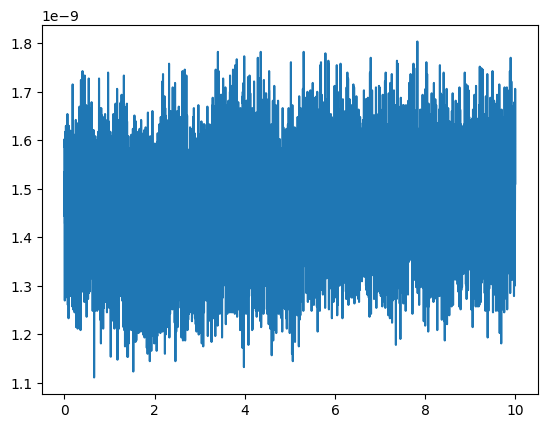

(MainThread) vmin 0.0653208007180445 vmax 765.4529560319329
(MainThread) ticklocs array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04])
(MainThread) vmin 0.0653208007180445 vmax 765.4529560319329
(MainThread) ticklocs array([2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04])
(MainThread) vmin 0.0653208007180445 vmax 765.4529560319329
(MainThread) ticklocs array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04])
(MainThread) vmin 0.0653208007180445 vmax

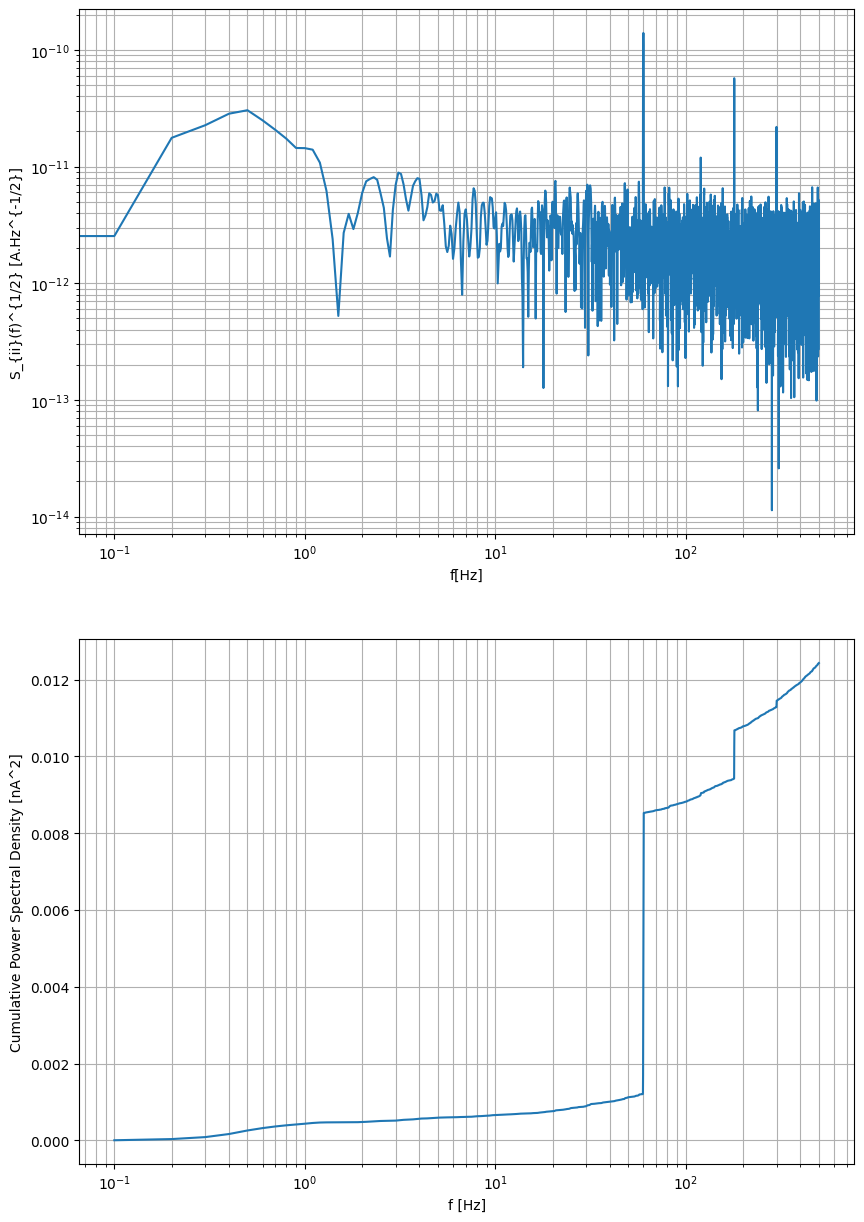

In [217]:
plt.plot(np.linspace(0,10,len(data)), data)
fig, ax = plt.subplots(nrows=2, ncols=1)
fig.set_figheight(15)
fig.set_figwidth(10)

f, II_den = signal.periodogram(
    data,
    fs = max_sampling_rate,
    window = "flattop",
    scaling = "density",
    return_onesided = True
)
ax[0].plot(f,np.sqrt(II_den))
ax[0].set_yscale("log")
ax[0].set_xscale("log")
ax[0].set_xlabel('f[Hz]')
ax[0].set_ylabel('S_{ii}(f)^{1/2} [A.Hz^{-1/2}]')
ax[0].grid(which='both')

cumulative = np.cumsum(II_den)[1:] * np.diff(f) * 1e18
ax[1].plot(f[1:], cumulative)
#ax[1].set_yscale("log")
ax[1].set_xscale("log")
ax[1].set_xlabel("f [Hz]")
ax[1].set_ylabel("Cumulative Power Spectral Density [nA^2]")
#ax[1].set_xlim((0, 60*10))
ax[1].grid(which='both')

In [214]:
print(rms_pA)

110.12707486069387


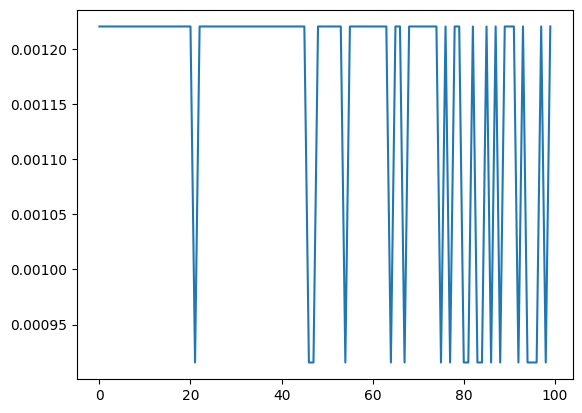

In [26]:
fastdacs[0].RAMP_SMART(1,0)
t_sampling = 0.1
data = read_fastdac_adc(0, 1, int(t_sampling * max_sampling_rate))
plt.plot(data)

In [99]:
times = [t for t, i in data]
vals = [i for t, i in data]

plot_1D(times, vals, x_label= "Time (s)", y_label= "Measured Voltage (V)")

TypeError: cannot unpack non-iterable numpy.float64 object

## Device Meas

4.342651367187499e-14
1.2341003417968749e-12
2.1240844726562505e-12
3.3128662109374995e-12
4.50177001953125e-12
5.4289855957031265e-12
6.619110107421874e-12
7.509063720703125e-12
8.69940185546875e-12
9.890045166015625e-12


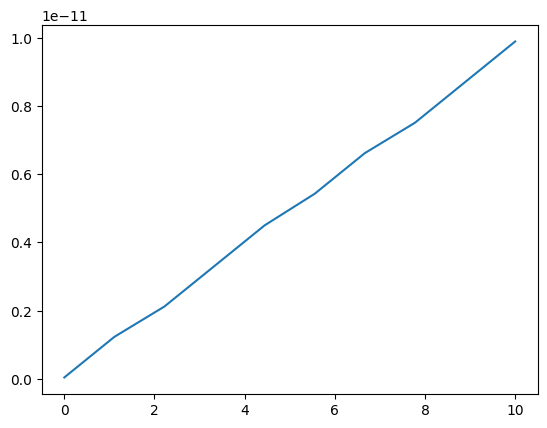

In [20]:
v_list = np.linspace(0,10,10)
plt.figure()
v_plot = []
i_plot = []

for v in v_list:
    t_sampling = 0.1
    fastdacs[0].RAMP_SMART(1,v)
    data = read_fastdac_adc(0, 0, int(t_sampling * max_sampling_rate))
    data = data / (1e8 * 1e3)
    data = np.mean(data)
    print(data)
    i_plot.append(data)
    v_plot.append(v)
plt.plot(v_plot,i_plot)
plt.show()

## Current Measurement

In [34]:
start_time = time.time()

with meas.run() as datasaver:
    while True:
        num_of_samples = int(1000 * t_acqu)
        data = read_fastdac_adc(0, 0, num_of_samples)
        data = data / (1e8)
        rms_pA = 1e12*np.sqrt(np.mean((data - np.mean((data)))**2))
        print(f"RMS noise {rms_pA} pA")
        t_desired = np.linspace(0, t_acqu, len(data))
        f, II_den = signal.periodogram(
            data,
            fs = 1000,
            window = "flattop",
            scaling = "density",
            return_onesided = True
        )

        current_time = time.time() - start_time

        datasaver.add_result(
            (elapsed_time, [current_time] * len(f)),
            (meas_freq, f),
            (fft_data, np.sqrt(II_den))
        )
        datasaver.add_result(
            (elapsed_time, [current_time] * len(t_desired)),
            (meas_time, t_desired),
            (trace_data, 1e12 * data)
        )
        datasaver.add_result(
            (elapsed_time, current_time),
            (meas_rms, rms_pA)
        )
        sleep((meas_seg - 1) * t_acqu)
        if current_time > total_meas_time:
            break

(MainThread) Created run with guid: e5b7b020-0000-0000-0000-019ac3fd2d17 in database C:\Users\Measurement6\Nextcloud2\Lab\Data\QSim\2025\20251117_NoiseData\fast_dac_noise.db
(MainThread) Set the run_timestamp of run_id 32 to 1764224740.6471708
(MainThread) Starting measurement with guid: e5b7b020-0000-0000-0000-019ac3fd2d17, sample_name: "SecondBOP12_RC_SHIELD_wo_ferrite_noise_data", exp_name: "2D sweep", ds_name: "results". 
(MainThread) Using background writing: False


Starting experimental run with id: 32. 


(MainThread) Flushing to database
(MainThread) Successfully wrote result to disk


RMS noise 106.77281036717521 pA


(MainThread) Flushing to database
(MainThread) Successfully wrote result to disk


...

RMS noise 107.99325075640637 pA


(MainThread) Flushing to database
(MainThread) Successfully wrote result to disk


RMS noise 111.50549234452231 pA


(MainThread) Flushing to database
(MainThread) Successfully wrote result to disk
(MainThread) An exception occurred in measurement with guid: e5b7b020-0000-0000-0000-019ac3fd2d17;
Traceback:
Traceback (most recent call last):
  File "C:\Users\Measurement6\AppData\Local\Temp\ipykernel_21028\4536126.py", line 6, in <module>
    data = read_fastdac_adc(0, 0, num_of_samples)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Measurement6\AppData\Local\Temp\ipykernel_21028\4150807833.py", line 15, in read_fastdac_adc
    val_array = fd.SPEC_ANA(channels=[adc_channel, ], steps=num_samples)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Measurement6\Documents\GitHub\QSTL_Example_Codes\FastDAC\FastDAC.py", line 417, in SPEC_ANA
    chunk = self.ser.read(2)
            ^^^^^^^^^^^^^^^^
  File "c:\Users\Measurement6\anaconda3\envs\qcodes\Lib\site-packages\serial\serialwin32.py", line 288, in read
    result_ok = win32.GetOverlappedResult

KeyboardInterrupt: 

## Voltage Measurement

In [19]:
start_time = time.time()

with meas.run() as datasaver:
    while True:
        num_of_samples = int(1000 * t_acqu)
        data = read_fastdac_adc(0, 0, num_of_samples)
        rms_V = np.sqrt(np.mean((data - np.mean((data)))**2))
        print(f"RMS noise {rms_V} mV")
        t_desired = np.linspace(0, t_acqu, len(data))
        f, II_den = signal.periodogram(
            data,
            fs = 1000,
            window = "flattop",
            scaling = "density",
            return_onesided = True
        )

        current_time = time.time() - start_time

        datasaver.add_result(
            (elapsed_time, [current_time] * len(f)),
            (meas_freq, f),
            (fft_data, np.sqrt(II_den))
        )
        datasaver.add_result(
            (elapsed_time, [current_time] * len(t_desired)),
            (meas_time, t_desired),
            (trace_data, data)
        )
        datasaver.add_result(
            (elapsed_time, current_time),
            (meas_rms, rms_V)
        )
        sleep((meas_seg - 1) * t_acqu)
        if current_time > total_meas_time:
            break

(MainThread) Created run with guid: 4179a847-0000-0000-0000-019ac3a0b68e in database C:\Users\Measurement6\Nextcloud2\Lab\Data\QSim\2025\20251117_NoiseData\fast_dac_noise.db
(MainThread) Set the run_timestamp of run_id 23 to 1764218680.9877205
(MainThread) Starting measurement with guid: 4179a847-0000-0000-0000-019ac3a0b68e, sample_name: "SecondBOP12_RC_NOT_SHIELD_big_ferrite_wo_femto_noise_data", exp_name: "2D sweep", ds_name: "results". 
(MainThread) Using background writing: False


Starting experimental run with id: 23. 


(MainThread) Flushing to database
(MainThread) Successfully wrote result to disk


RMS noise 0.0 mV


(MainThread) Flushing to database
(MainThread) Successfully wrote result to disk


...

RMS noise 0.0 mV


(MainThread) Flushing to database
(MainThread) Successfully wrote result to disk


RMS noise 0.0 mV


(MainThread) Flushing to database
(MainThread) Successfully wrote result to disk
(MainThread) Flushing to database
(MainThread) Successfully wrote result to disk
(MainThread) Finished measurement with guid: 4179a847-0000-0000-0000-019ac3a0b68e. 


RMS noise 0.0 mV
